make saw tooth
approximate N3 using N1 and N2
same but smoothed

find N3 based on N3_hat and find N1 based on N1_hat

https://en.wikipedia.org/wiki/Unsharp_masking
digital unsharpening mask [0 1 0] + ([0 1 0] - [1 1 1] /3) * 3 = [-1, 3, -1]
vary multiplier

https://en.wikipedia.org/wiki/Kernel_(image_processing)
ridge or edge detection

unsharp masking with gaussian blur

R-L deconvolution

In [1]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)
print(matplotlib.get_cachedir())

import matplotlib.font_manager as fm
fm.findSystemFonts(fontpaths=None, fontext="ttf")
#print(fm.get_cachedir())
print(sorted(fm.get_font_names()))

3.9.3
C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\matplotlib\__init__.py
C:\Users\florianma\.matplotlib
['72', '72 Monospace', 'Agency FB', 'Algerian', 'Arial', 'Arial Rounded MT Bold', 'Arial monospaced for SAP', 'Bahnschrift', 'Baskerville Old Face', 'Bauhaus 93', 'Bell MT', 'Berlin Sans FB', 'Berlin Sans FB Demi', 'Bernard MT Condensed', 'Blackadder ITC', 'Bodoni MT', 'Book Antiqua', 'Bookman Old Style', 'Bookshelf Symbol 7', 'Bradley Hand ITC', 'Britannic Bold', 'Broadway', 'Brush Script MT', 'Calibri', 'Californian FB', 'Calisto MT', 'Cambria', 'Candara', 'Castellar', 'Centaur', 'Century', 'Century Gothic', 'Century Schoolbook', 'Chiller', 'Colonna MT', 'Comic Sans MS', 'Consolas', 'Constantia', 'Cooper Black', 'Copperplate Gothic Bold', 'Copperplate Gothic Light', 'Corbel', 'Courier New', 'Curlz MT', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Dubai', 'Ebrima', 'Edwardian Script ITC', 'Elephant', 'Engravers 

In [2]:
import numpy as np
from scipy.ndimage import convolve1d
import matplotlib.pyplot as plt
from ezyrb import ReducedOrderModel as ROM
from ezyrb import POD
from ezyrb import Database as DB
from ezyrb.approximation import Linear
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters_single
import warnings
warnings.simplefilter(action='once')

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
# mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
mpl.rc('font', family='serif', size=fs, serif='Times New Roman')
pth = "../Plots/"
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
#pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
markevery = 100

8.030570172000001


In [4]:
m = 1000
x = np.linspace(0, 1, m+1, endpoint=True)
dx = x[1]-x[0]

In [5]:
def approximate(A, N3):
    coefficients, _, _, _ = np.linalg.lstsq(A, N3, rcond=None)
    #print(coefficients)
    return np.sum(A*coefficients, axis=-1)

def approximate2(mu, ss):
    training_db = DB(mu, ss)
    reduction = POD(method="svd", rank=2)
    approximation = Linear()
    rom = ROM(training_db, reduction, approximation)
    rom.fit()
    res = rom.predict([0.5]).snapshots_matrix[0]
    return res

In [6]:
def f11(x, mu, w=0.1+1e-6):
    # original
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y

def f1(x, mu, w=0.1+1e-6):
    mu = mu-w
    #w = w*2
    y = np.zeros_like(x, dtype=np.float64)
    nonzero = (0-1e-6 < (x-mu)) & ((x-mu) < w)
    y[nonzero] = 1/w * (x[nonzero]-mu)
    #y[y>0.0] = 1
    #y[y<0.1] = 0
    return y

def f2(x, mu):
    # moving averagee
    y = f1(x, mu)
    k = np.ones((250,))/250
    return np.convolve(y, k, mode='same')


def f3(x, mu, w=0.1+1e-6, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = x[1]-x[0]  # 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx, mode="wrap")
    return y2


def relative_error(approx, truth):
    abs_error = np.mean((approx-truth)**2)**.5
    return abs_error/np.mean((truth)**2)**.5

In [7]:
def gaussian(x, sigma, shift=True):
    print("get g")
    dx = x[1]-x[0]
    A = dx/(sigma*(2*np.pi)**.5)
    return A * np.exp(-x**2 / (2 * sigma**2))

def riemann_sum_equispaced(x, y):
    dx = np.mean(np.diff(x))
    return np.sum(dx*y)
    

get g
get g
get g
1.0000000000000009


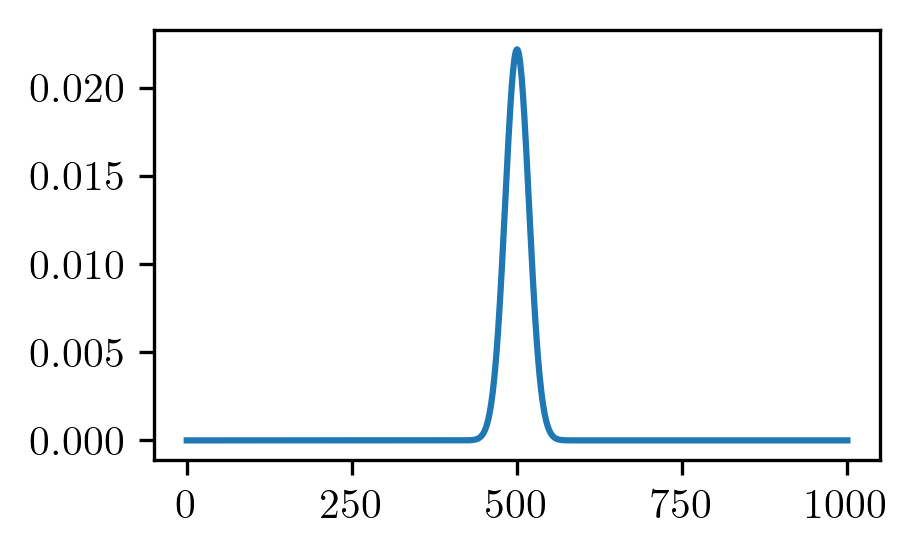

0.04950050499495007
0.04950050499495007
0.049500504994950074
0.04950050499495007


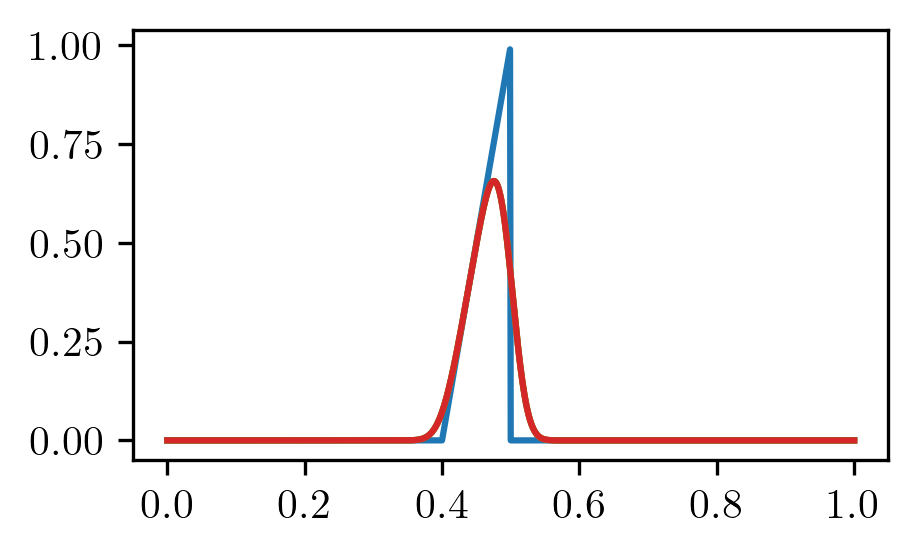

In [8]:
sigma_S = 0.018

y = f1(x, 0.5)
ys1 = gaussian_filter1d(y, sigma=sigma_S/dx, mode="wrap")
krnl = gaussian(x-0.5, sigma=sigma_S)+gaussian(x-1.5, sigma=sigma_S)+gaussian(x+.5, sigma=sigma_S)
#krnl = krnl/np.sum(np.sum(krnl))

plt.plot(krnl)
print(np.sum(krnl))
plt.show()
ys2 = convolve1d(y, krnl, mode="wrap")
ys3 = f3(x, 0.5, s=sigma_S)

plt.plot(x, y)
plt.plot(x, ys1, label="gaussian filter")
plt.plot(x, ys2, label="convolve1d with gaussian kernel")
plt.plot(x, ys3, label="f3")


print(riemann_sum_equispaced(x, y))
print(riemann_sum_equispaced(x, ys1))
print(riemann_sum_equispaced(x, ys2))
print(riemann_sum_equispaced(x, ys3))

sigma, c, iteration count, mean_ROM, mean_sROM, mean_sROMs, improvement
post_process: 0.005 1.0 250 (1001,) True
0.00500000, 1.00000000, 0, 0.07126304, 0.06118571, 0.10199740, 43.1280 %
post_process: 0.0055 1.0 250 (1001,) True
0.00550000, 1.00000000, 1, 0.07126304, 0.06053106, 0.09482781, 33.0673 %
post_process: 0.005 1.05 250 (1001,) True
0.00500000, 1.05000000, 2, 0.07126304, 0.06118571, 0.10083994, 41.5038 %
post_process: 0.04886961447744397 9.999998680850329 250 (1001,) True


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:33: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


0.04886961, 9.99999868, 3, 0.07126304, 0.11438547, 0.08993130, 26.1963 %
post_process: 0.027255488340772113 5.565788145040912 250 (1001,) True
0.02725549, 5.56578815, 4, 0.07126304, 0.08590223, 0.12257044, 71.9972 %
post_process: 0.01561374415503742 3.1774452438676923 250 (1001,) True
0.01561374, 3.17744524, 5, 0.07126304, 0.06788200, 0.13071321, 83.4236 %
post_process: 0.009648065523017047 1.9535662456566147 250 (1001,) True
0.00964807, 1.95356625, 6, 0.07126304, 0.06045047, 0.09381136, 31.6410 %
post_process: 0.007560253305780814 1.5252445604808642 250 (1001,) True
0.00756025, 1.52524456, 7, 0.07126304, 0.05947506, 0.03186439, -55.2862 %
post_process: 0.008060253305780814 1.5252445604808642 250 (1001,) True
0.00806025, 1.52524456, 8, 0.07126304, 0.05955993, 0.04268122, -40.1075 %
post_process: 0.007560253305780814 1.5752445604808643 250 (1001,) True
0.00756025, 1.57524456, 9, 0.07126304, 0.05947506, 0.03523039, -50.5629 %
post_process: 0.00906061415759677 0.0005570867897664034 250 (1

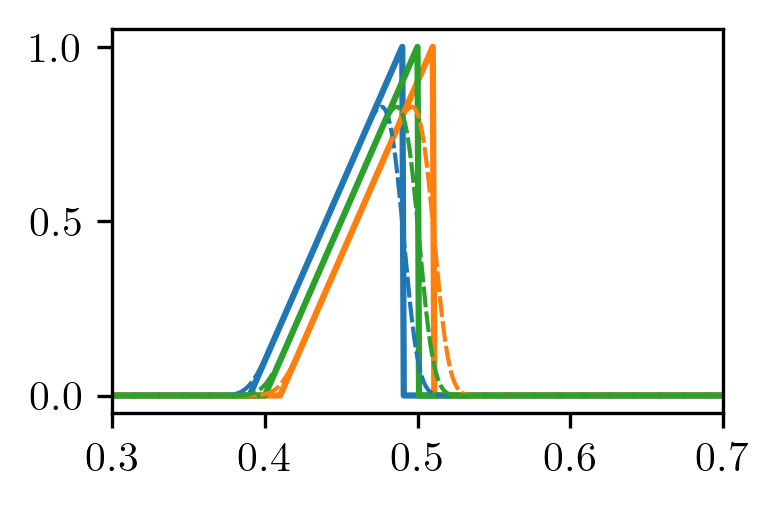

riemann 0.050499999999999996
riemann 0.050499999999999975
riemann 0.050499999999999996
riemann 0.05049999999999996
riemann 0.050499999999999975
riemann 0.05049999999999999


In [9]:
# sigma_S = 0.1
# cases = ["separated", "adjacent", "overlapping"]
# distances = [0.15, 0.1, 0.05]
# sigmaSs = [0.3, 0.15, 0.075]

# for row in range(3):
# case = cases[row]
# d = distances[row]

# 0.07677147684485953 3.21067009515133
# 0.15924288424530114 1.21443258945469
# 0.04277969256398406 1.180739585076126

d = 0.01
N1 = f1(x, 0.5-d, w=0.1)  
N2 = f1(x, 0.5+d, w=0.1)  
N3 = f1(x, 0.5, w=0.1) 

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, N1)
plt.plot(x, N2)
plt.plot(x, N3)
#plt.show()
#print("x1, x2=", 0.5-d, 0.5+d)

A = np.vstack([N1, N2]).T
# N3_hat = approximate(A, N3)
N3_hat = approximate2(np.array([[0.5-d], [0.5+d]]), A.T)


mu_train = np.array([[0.5-d], [0.5+d]])
mu_test = np.array([[0.5]])
X_train = np.c_[N1, N2]
X_test = N3[:, None]
shape = x.shape
clip = True
rank = 100  # 1/d
num_iter2 = 250

#     print(mu_train.shape, X_train.shape)
#     print(mu_test.shape, X_test.shape)

sigma_S, c = optimize_hyperparameters_single(x, mu_train, mu_test, X_train, X_test,
                                       shape, num_iter2, clip, rank)
print(sigma_S, c)
        
N1_s = f3(x, 0.5-d, w=0.1, s=sigma_S)
N2_s = f3(x, 0.5+d, w=0.1, s=sigma_S)
N3_s = f3(x, 0.5, w=0.1, s=sigma_S)
A = np.vstack([N1_s, N2_s]).T
# N3_s_hat = approximate(A, N3_s)
N3_s_hat = approximate2(np.array([[0.5-d], [0.5+d]]), A.T)

#fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, N1_s, "C0", ls=(0, (5, 1)), lw=1)
plt.plot(x, N2_s, "C1", ls=(0, (5, 1)), lw=1)
plt.plot(x, N3_s, "C2", ls=(0, (5, 1)), lw=1)
#plt.plot(x, res, "C3", ls=(0, (5, 1)), lw=1)
plt.xlim([0.3, 0.7])
plt.show()

print("riemann", riemann_sum_equispaced(x,  N1))
print("riemann", riemann_sum_equispaced(x,  N2))
print("riemann", riemann_sum_equispaced(x,  N1_s))
print("riemann", riemann_sum_equispaced(x,  N2_s))
print("riemann", riemann_sum_equispaced(x,  N3_s))

print("riemann", riemann_sum_equispaced(x,  N3_s_hat))
#print("riemann", riemann_sum_equispaced(x,  res))


sharpening filter np.array([-1, 3, -1])
- vary multiplier
- vary sigD

In [10]:
print(np.sum((N3-N3_s_hat)**2)**.5)

1.882312328012211


0.007761773274857583
get g
get g
get g
1.8369713442242466
1.8183177786186597
1.8271691694546879
1.8631335456150606
1.9246916243938756
riemann 0.050499999999999975
riemann 0.050499999999999975
riemann 0.050499999999999975
riemann 0.050499999999999975
riemann 0.050499999999999975


<>:15: SyntaxWarning: invalid escape sequence '\h'


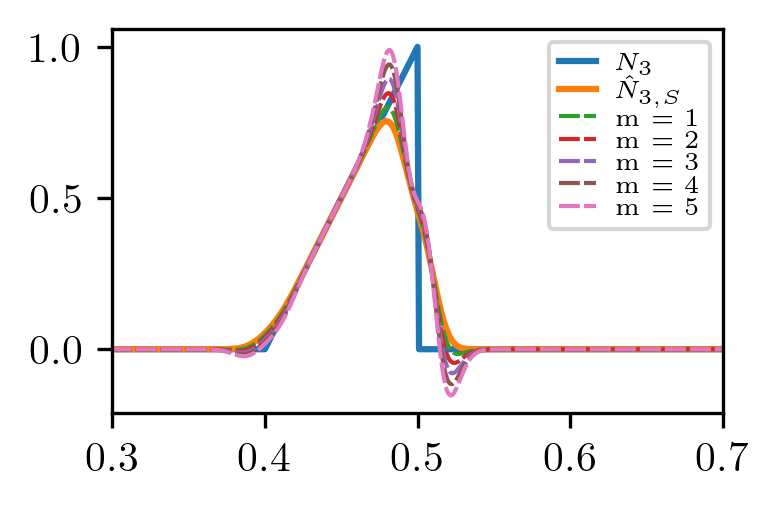

0.015523546549715167
get g
get g
get g
1.7488528503643257
1.8768924597750463
2.221669808991819
2.701436765149868
3.257077965495046
riemann 0.05049999999999985
riemann 0.05049999999999985
riemann 0.05049999999999985
riemann 0.05049999999999985
riemann 0.05049999999999985


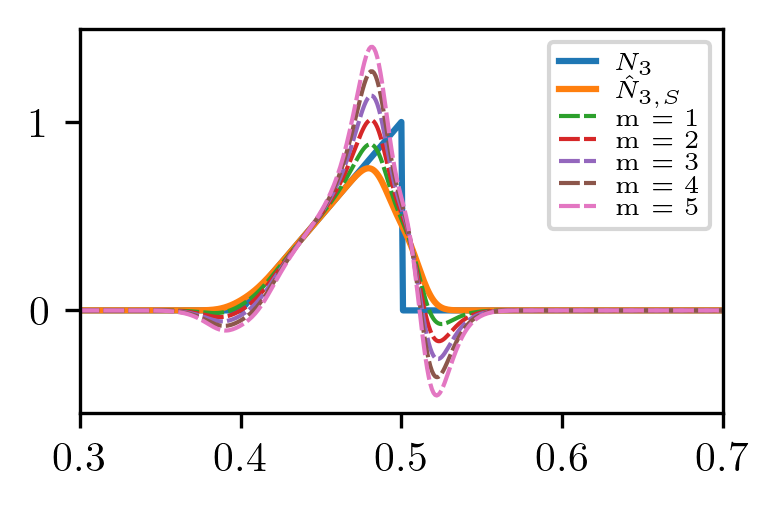

0.012882346716183983
get g
get g
get g
1.7668382300839427
1.7983792462699817
1.9698861506625294
2.2495706103073325
2.602790303880431
riemann 0.05049999999999981
riemann 0.05049999999999981
riemann 0.05049999999999981
riemann 0.05049999999999981
riemann 0.05049999999999981


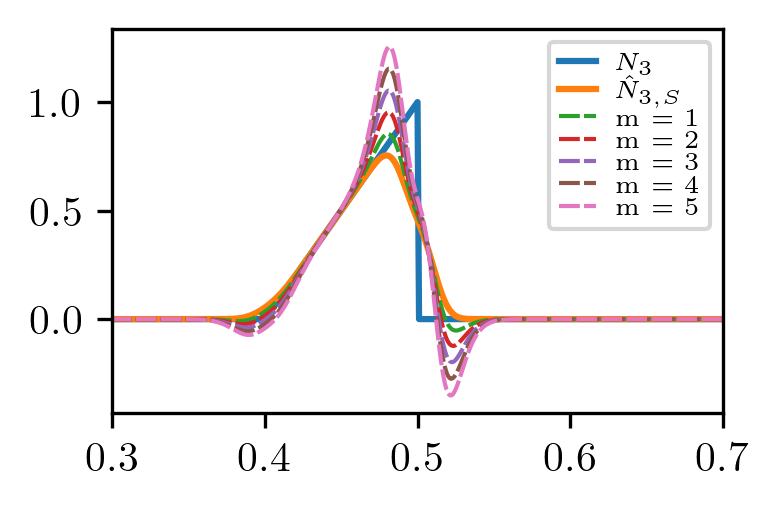

In [11]:
mp = 1
# sigs, c = 0.00776175, 1.31943973

I = np.zeros_like(x)
I[m//2] = 1

for sigma_D in [sigma_S, 2*sigma_S, sigma_S*(1+0.5*c)]:
    print(sigma_D)
    gs = gaussian(x-0.5, sigma=sigma_D)+gaussian(x-1.5, sigma=sigma_D)+gaussian(x+.5, sigma=sigma_D)
    #kernel = I + (I - gs) * mp


    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(x, N3, label="$N_3$")
    plt.plot(x, N3_s_hat, label="$\hat{N}_{3,S}$")
    for mp_ in [1, 2, 3, 4, 5]:
        kernel = I + (I - gs) * mp_
        N3_k = np.convolve(N3_s_hat, kernel, mode="same")
        plt.plot(x, N3_k, label="m = "+str(mp_), ls=(0, (5, 1)), lw=1)
        print(np.sum((N3-N3_k)**2)**.5)
    for mp_ in [1, 2, 3, 4, 5]:
        print("riemann", riemann_sum_equispaced(x,  N3_k))
    plt.legend()
    plt.xlim([0.3, 0.7])
    plt.tight_layout()
    plt.savefig(pth+"sharpening_multiplier_s{:.4f}.pdf".format(sigma_D))
    plt.show()

# edge detection using a discrete laplace operator np.array([-1, 2, -1])

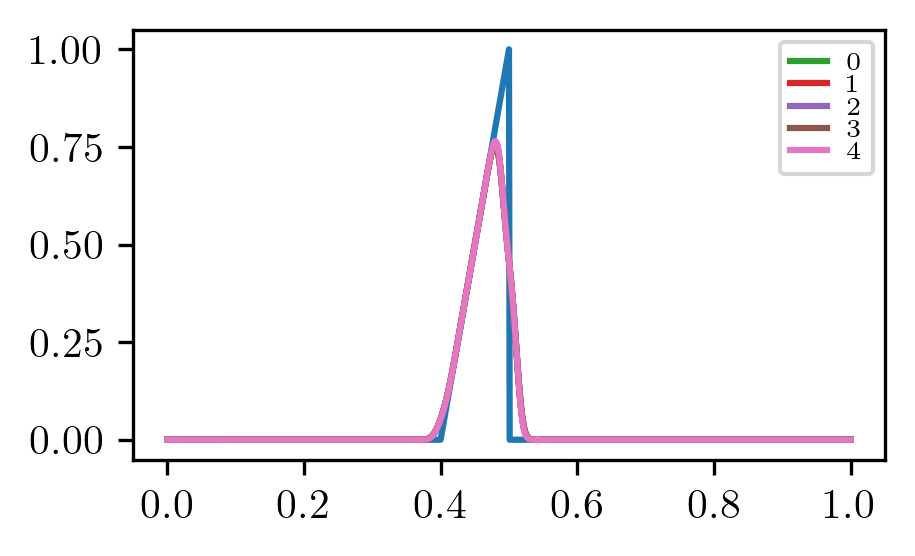

In [12]:
plt.plot(x, N3)
plt.plot(x, N3_s_hat)
N3_k = N3_s_hat
for k in range(5):
    kernel = np.array([-1, 3, -1])
    N3_k = np.convolve(N3_k, kernel, mode="same")
    plt.plot(x, N3_k, label=str(k))
plt.legend()
plt.show()

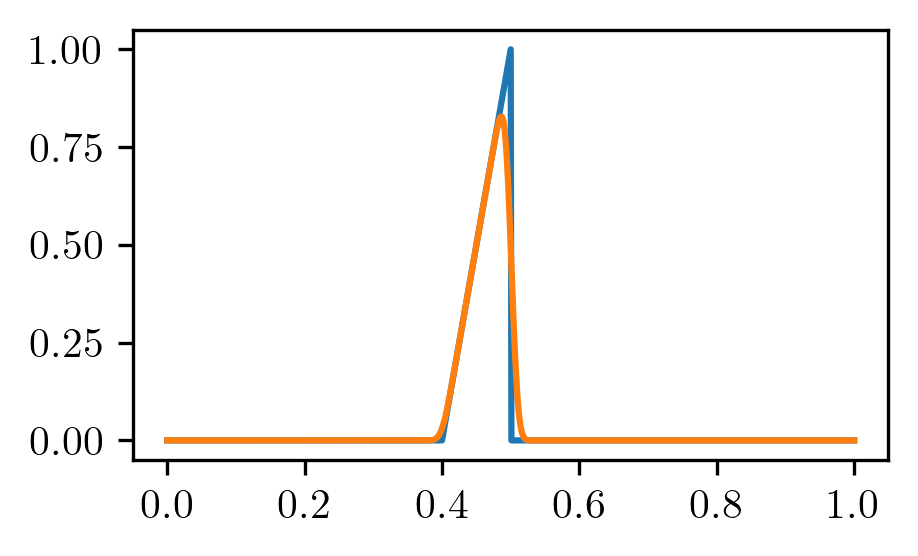

In [13]:


plt.plot(x, N3)
plt.plot(x, N3_s)

edge detection using a discrete laplace operator np.array([-1, 2, -1])

In [14]:
from smooth_POD_ROM.post_processing import post_process, richardson_lucy
from smooth_POD_ROM.post_processing import get_sigma, relative_distance_nearest_neighbour
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, smoothen
from smooth_POD_ROM.reduced_order_model import delta_n_width, train_ROM, L2_error, zielfunktion


In [15]:
num_iter = 5000
dx = x[1]-x[0]

standard_rom = train_ROM(mu_train, X_train, rank=rank)
ss_test_ROM = standard_rom.predict(mu_test[0, None]).snapshots_matrix.T

print(ss_test_ROM.shape)


e_ROM = L2_error(ss_test_ROM, N3[:, None])

improvements = np.empty((num_iter))
X_train_s = smoothen(X_train, sigma_S/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
ss_test_sROM = smooth_rom.predict(mu_test[0, None]).snapshots_matrix.T
ss_test_sROMs, sss = richardson_lucy(x, ss_test_sROM.reshape(shape),
                                     sigma_D, num_iter, truth=None,
                                     damping=2, clip=clip,
                                     monitor_convergence=True)
ss_test_sROMs-X_test[:, 0, None]
e_k = np.mean((sss-X_test)**2, axis=0)**.5
improvements = 100*e_k/e_ROM-100
print(np.min(improvements))

(1001, 1)
-64.64955152612728


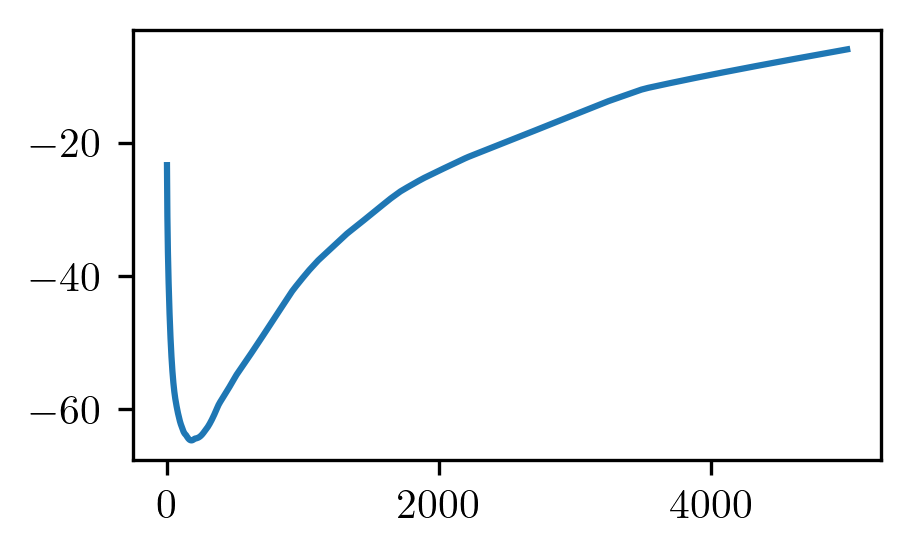

In [16]:
plt.plot(improvements)

In [17]:
relative_distance_nearest_neighbour(mu_test, mu_train)

np.float64(0.5)

In [18]:
get_sigma(sigma_S, mu_test, mu_train, c)

np.float64(0.012882346716183983)

riemann N3 0.05049999999999999
riemann N3_s 0.050499999999999975
riemann N_3S hat 0.05049999999999999
riemann  0.050499999999999975
riemann  0.05049999999999998
riemann  0.05048600859979977
error N3 1.882312328012211
error 1.7274670323750148
error 1.388308242935713
error 0.8555501818215735


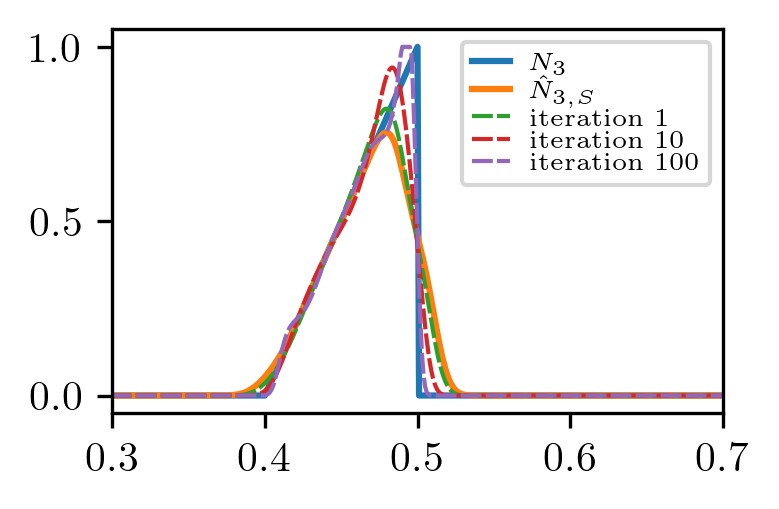

In [19]:

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))

plt.plot(x, N3, label="$N_3$")
plt.plot(x, N3_s_hat, label="$\hat{N}_{3,S}$")
print("riemann N3", riemann_sum_equispaced(x, N3))
print("riemann N3_s", riemann_sum_equispaced(x, N3_s))
print("riemann N_3S hat", riemann_sum_equispaced(x, N3_s_hat))
for i in [0, 9, 99]:
    print("riemann ", riemann_sum_equispaced(x,  sss[:, i]))

print("error N3", np.sum((N3-N3_s_hat)**2)**.5)
for i in [0, 9, 99]:
    plt.plot(x, sss[:, i], label="iteration "+str(i+1), ls=(0, (5, 1)), lw=1)
    print("error", np.sum((N3-sss[:, i])**2)**.5)
    
plt.legend()
plt.xlim([0.3, 0.7])
plt.tight_layout()
plt.savefig(pth+"RL_decon.pdf")
plt.show()



In [20]:
(1-0.050499999999999975/0.05048600859979977)*100


-0.027713421179931252